<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/Aberrations/GS_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a code to implement the Gerbercht Saxton algorihtm to first order

In the propagation of the fiedl we use eigher the FFT far field propagation or the Fresnel propagation in the near field.

Gaussbeam(xx,yy,z,k0,w0,foc) is a reoutine to compute the Complex Gaussian field.  The difference is that the z coordinate is computed with respecgt to the focal plane ($z_f = z- f$).

ProgatorK(x,U0,k0,dz) is the routine to propagate by Fresnel the field on z=0 ($U_0$). The propagator is:
$$ U_z = iFFT\{FFT\{U_o\} \cdot exp[ik_z z ] \} \simeq iFFT\{FFT\{U_o\} \cdot exp[-ik^2 z /(2k_o) ] \} $$
where we disregard a term $excp\{ i k_o z\}$.


In [ ]:
"""
Gerberch-Saxton exploration

These are usefule routines

Giberto 17 May 2024

"""
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import pandas as pd

################################################
def Gaussbeam(xx,yy,z,k0,w0,foc):
    zR = w0*w0*k0/2.
    zf = z-foc
    rr = xx**2 +yy**2
    Gbeam = zR/(zR-1j*zf) * np.exp(-k0*rr/(2*(zR-1j*zf)))
    """
    print ('comp w0 =',2*foc/(k0*w0)/np.sqrt(1 + (foc/zR)**2),' um')
    print ('Rayleigh range=',zR, 'EP diameter=', w0*np.sqrt(1 + (foc/zR)**2))
    print (zf)
    """
    return Gbeam
##################################################
"""
    Propagator in the Fourier space
    x is the 1D vecotr of the x coordinate (y must be the same) they are used in the main code
        to compute the meshgrid

    U0 is the field at z_in
    dz is the displacement in z
    k0 = 2pi/wavelength
    output:
    Uz is the field propagated at z= z_in + dz
"""
def ProgatorK(x,U0,k0,dz):
    #### NOTICE. AS IT IS dz must be negative to propagate forward!!!!!
    if U0.shape[0] != U0.shape[1]:
        print ('error on U, it is not square')
    ######### must be squared
    NN    = U0.shape[0]
    NNx   = x.shape[0]
    dx    = x[1]-x[0]

    if (NN != NNx):
        print ('error on the size, x.size is not U.size[0]')
    #print ('NN=',NN,'; dx=',dx)

    Ufft    = np.fft.fft2(U0)    ####2D FFT  of the oriignal field
    Ffreq   = 2*np.pi* np.fft.fftfreq(NN,dx)#### q is not the frequnecy!!!!!!
    ffx,ffy = np.meshgrid(Ffreq,Ffreq)
    F2      = ffx*ffx + ffy*ffy
    phase   = F2*dz/2/k0

    ### print ('max phase:', phase.max(),F2.max(),k0)

    E       = np.exp(-1j*phase) ## propagator

    Uz      = np.fft.ifft2(E*Ufft)
    return(Uz)

############# standard GS algorithm with FFT
def GS_Python(img, maxIter):

    height, width = img.shape
    # ---- "Fourier" is the SLM or pupil
    # ---- "Space" is the sample plane or the eye retina
    # ---  Assumptions are made on the intnsity profiles on the two planes
    measuredAmplitudeSpace    = np.sqrt(img)
    measuredAmplitudeFourier  = np.ones((height, width))

    # --- Starting point
    currentPhaseSpace         = np.random.rand(height, width)
    # --- Initialization
    currentPhaseFourier       = np.ones((height, width))
    # ---- starting Efield on Sample plane
    currentSpace = measuredAmplitudeSpace * np.exp(currentPhaseSpace * 1j)

    for iter in range(maxIter):
        # --- Enforce measured amplitude constraint in the Fourier domain
        currentFourier            = np.fft.fft2(currentSpace)
        currentPhaseFourier       = np.angle(currentFourier)
        currentFourier            = measuredAmplitudeFourier * np.exp(1j * currentPhaseFourier)

        # --- Enforce measured amplitude constraint in the spatial domain
        currentSpace              = np.fft.ifft2(currentFourier)
        currentPhaseSpace         = np.angle(currentSpace)
        currentSpace              = measuredAmplitudeSpace * np.exp(1j * currentPhaseSpace)

    return currentPhaseFourier
########################  rebin  a matrix
def Mat_reduce(A,m):
    N,N= A.shape
    m = int(m/2)*2
    Ar = np.zeros((N,N))
    for i in np.arange(0,N,m):
        for j in np.arange(0,N,m):
            for k in range(m):
                for h in range(m):
                    Ar[i+k,j+h] = A[i,j]
    return Ar

sample is : pattern
(129, 135) (64, 64) (64, 64)
<Error>= 11.32  +/- 4.8
34.56385520317348 0.0
1.0 0.0


Text(0.5, 0.98, 'GS with Maxiter=25')

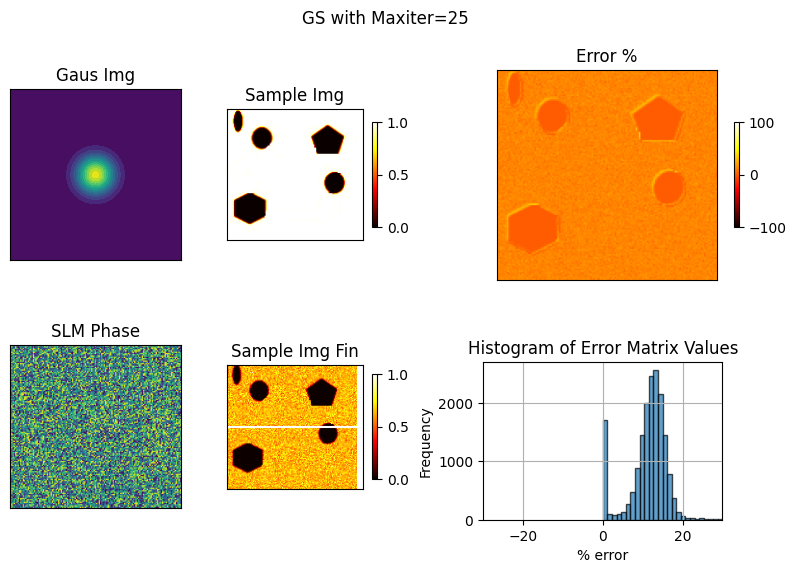

<Figure size 640x480 with 0 Axes>

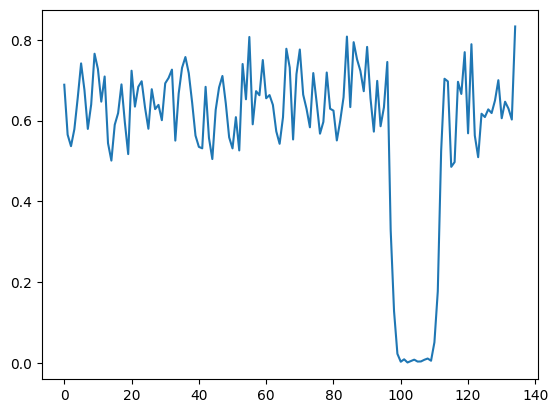

In [ ]:

########################## if you want to import a pattern...
from PIL import Image
import matplotlib.gridspec as gridspec  # Import gridspec

def controlla_img(img,img_fin):
  print (img_fin.max(), img_fin.min())
  print (img.max(), img.min())
# Check for NaN values
  has_nan = np.isnan(img_fin).any()

# Check for Inf values
  has_inf = np.isinf(img_fin).any()

  if has_nan:
      print("The matrix contains NaN values.")
  if has_inf:
      print("The matrix contains Inf values.")
  return 0

#### in case you want to open a specific pattern you must upload in colab drive and
### copy the path
# Open an image file

image       = Image.open("/content/pasttern1.jpg")
gray_image  = image.convert("L")
pattern1    = np.array(gray_image)
image       = Image.open("/content/pasttern2.jpg")
gray_image  = image.convert("L")
pattern2    = np.array(gray_image)

################# define ALL UNITS IN micrometers
k0      = 2*np.pi/0.8 ### in 1/um
N       = 64
w0      = 3
foc     = 8000   ### um
Dz      = 3
z       = foc-Dz ##
####################  spacing in SLM  plane
x       = np.linspace(-10,10,N)   #### in um
xx,yy   = np.meshgrid(x,x)
height, width = xx.shape

FLAGp    = 'pattern2' ## or  'Gauss
############## load a specific pattern or create two spots with fringes
alfaM     = 1 ## radiants
maxIter   = 25 #fior the GS algorithm
contatore = 0
Gbeam0    = Gaussbeam(xx,yy,z,k0,w0,foc)  ##computed in z-foc = foc-Dz - foc = -Dz with respct to the focal plan e

######    show : open figiures  ########
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 2])  # Last column is wider

# Subplots for the first two columns
A1 = fig.add_subplot(gs[0, 0])  # Top-left
A2 = fig.add_subplot(gs[0, 1])  # Top-middle
A3 = fig.add_subplot(gs[1, 0])  # Bottom-left
A4 = fig.add_subplot(gs[1, 1])  # Bottom-middle
for a in [A1, A2, A3, A4]:
  a.set_aspect('equal')
  a.set_xticks([])
  a.set_yticks([])
## avoid to show the labels

# Large imshow subplot spanning both rows in the third column
A5 = fig.add_subplot(gs[0, 2])  # upper right column
A5.set_xticks([])
A5.set_yticks([])
A6 = fig.add_subplot(gs[1, 2])  # upper right column
#### show the initial distribution of intentisyt
A1.contourf(xx,yy,np.abs(Gbeam0)**2,levels = 12)
A1.set_title('Gaus Img')
##################
############  randomphase for scattering
scatAmp     = 0.001
RandPhase   = np.pi - 2*np.pi*np.random.rand(height, width)
RandPhase_4 = scatAmp*Mat_reduce(RandPhase,4)

######################################################
########## choose patterns  ##################

if FLAGp == 'Gauss':
  print ('sample is : ',FLAGp)
  alfax     = alfaM
  alfay     = np.sqrt(alfaM**2 - alfax**2)
  if (alfax <0):
    alfay = -alfay
  print (alfax,alfay)

  GbeamT    = Gbeam0*np.exp(1j*xx*alfax+1j*yy*alfay) + Gbeam0*np.exp(-1j*xx*alfax-1j*yy*alfay)
  E_sample  = ProgatorK(x,GbeamT*np.exp(1j*RandPhase_4),k0,-Dz)
  print ('sample is : Gauss')
elif FLAGp == 'pattern1':
  E_sample  = pattern1*np.exp(1j*0)
  img_in    = np.abs(E_sample)**2
  print ('sample is : pattern')
elif FLAGp == 'pattern2':
  E_sample  = pattern2*np.exp(1j*0)
  img_in    = np.abs(E_sample)**2
  print ('sample is : pattern')
else:
  print ('NO PATTERN DETECTED ')

print (E_sample.shape, RandPhase.shape, RandPhase_4.shape)
#############   show starting point
img = np.abs(E_sample)**2
img       = (img-img.min()) / (img.max()-img.min())

I01       = A2.imshow(img,cmap='hot')
A2.set_title('Sample Img')
plt.colorbar(I01,ax=A2,shrink=0.5)

#############  this is the Gerbert-Saxton algorithm ### standard FT GS
Phase     = GS_Python(img_in, maxIter)   ### standard FT GS

A3.imshow(np.fft.fftshift(Phase))
A3.set_title('SLM Phase')


###final, but needs to be flipped ud and lr

E_sample    = np.fft.fft2(np.exp(1j*Phase))
img_fin     = np.abs(E_sample)**2
img_fin     = (img_fin-img_fin.min()) / (img_fin.max()-img_fin.min())
img_fin     = np.flipud(np.fliplr(img_fin))  ##### FLIP
I11         = A4.imshow(img_fin,cmap='hot')
A4.set_title('Sample Img Fin')
plt.colorbar(I11,ax=A4,shrink=0.5)

################## Error matrix

ERR_img     = 100* 0.5*np.abs(img_fin-img) / np.mean(img_fin + img)
num = np.sqrt(np.mean((img_fin - img)**2))
den = np.mean(img_fin + img)


print ('<Error>=',round(ERR_img.mean(),2),' +/-',round(ERR_img.std(),2))
controlla_img(img_fin,ERR_img)

I5          = A5.imshow(ERR_img,cmap='hot',vmin=-100,vmax=100)
plt.colorbar(I5,ax=A5,shrink=0.5)
A5.set_title('Error %')


plt.figure()
############ now compute tyhe histogram of the errors
pos = A6.get_position()  # gets current position [left, bottom, width, height]
A6.set_position([pos.x0 + 0.04,   # shift slightly right
                 pos.y0 + 0.02,   # shift slightly up
                 pos.width * 0.7, # shrink width to 75%
                 pos.height * 0.75 # shrink height to 75%
                 ])
A6.hist(ERR_img.flatten(), bins=30, edgecolor='black', alpha=0.7)  # 30 bins for better distribution
A6.set_xlabel("% error")
A6.set_ylabel("Frequency")
A6.set_xlim(-30,30)
A6.set_title("Histogram of Error Matrix Values")
A6.grid(True)


#Phase2    = Phase
Phase2    = Phase
plt.figure()
plt.plot(img_fin[img_fin.shape[0]//2,:])

A4.plot([0,img_fin.shape[1]],[img_fin.shape[0]//2,img_fin.shape[0]//2],c='white')

fig.suptitle('GS with Maxiter='+str(maxIter))

ASSUME THAT THERE ARE TWO PREVISOULòY COMPUTED PHASES


<ipython-input-7-3b30893e2c07>:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

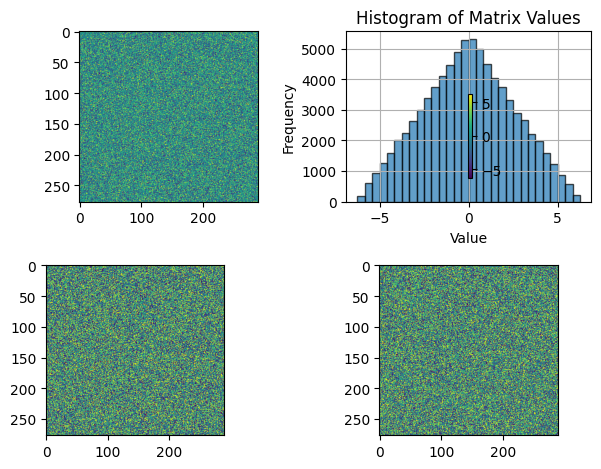

In [ ]:
plt.figure()
print ('ASSUME THAT THERE ARE TWO PREVISOULòY COMPUTED PHASES')
matrix      = Phase2-Phase1
F,A         = plt.subplots(2,2)
a0          = A[0,0].imshow(matrix)
plt.colorbar(a0,ax=A[0],shrink = 0.5)


# Flatten the matrix into a 1D array for histogram computation
values = matrix.flatten()

# Plot the histogram
A[0,1].hist(values, bins=30, edgecolor='black', alpha=0.7)  # 30 bins for better distribution
A[0,1].set_xlabel("Value")
A[0,1].set_ylabel("Frequency")
A[0,1].set_title("Histogram of Matrix Values")
A[0,1].grid(True)

A[1,0].imshow(Phase2)
A[1,1].imshow(Phase1)
plt.tight_layout()
plt.show()



The following is to test the possibility to dump three equal amplitude spots on a SLM
Possibly with a aberration.

3.1 -3.2 (64, 64) (64,)
0 alpha= 0.0  rads; xprime= 0.0  um
1 alpha= 0.17  rads; xprime= 1.07  um
2 alpha= 0.33  rads; xprime= 2.13  um
3 alpha= 0.5  rads; xprime= 3.2  um
4 alpha= 0.67  rads; xprime= 4.27  um
5 alpha= 0.83  rads; xprime= 5.33  um


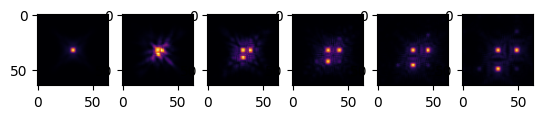

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

#################
def dilateMat(M):
  maschera  = np.ones((3,3))
  Mdilat    = convolve2d(M, maschera, mode='same')
  return Mdilat

###########  physical parameters

wav     = 2*np.pi/k0
#####à spatial parameters
rho     = np.sqrt(xx*xx+yy*yy)
angolo  = np.atan2(yy,xx)
########## aberrations , spherical and astigmatism
Ash     = 0.001
Aas     = 0.0009
Fase    = Ash * (rho**4 - rho**2) + Aas * rho*np.cos(angolo) ### aberrated phase

E_0 = np.ones(xx.shape) * np.exp(1j*Fase)  # background phase + aberrations

dimx,dimy = E_0.shape
NP = 6  ## nu,mber of spots
F, A = plt.subplots(1,NP)

freq    = np.fft.fftfreq(dimx,1)  ### Fourier frequencies

xprime  = freq *foc * wav /1000  ### focal plan coordinates
yprime  = freq *foc * wav / 1000
xxp,yyp   = np.meshgrid(xprime,yprime)
print (xxp.max(),xxp.min(),xxp.shape,xprime.shape)

for k in range(NP):
    alpha = float(k)/6
    print(k, 'alpha=',np.round(alpha,2), ' rads; xprime=',np.round(alpha *foc*wav/1000,2),' um')
    Prismx = np.exp(1j * 2 * np.pi * alpha * xx)
    Prismy = np.exp(1j * 2 * np.pi * alpha * yy)

    E_slm     = E_0 * Prismx + E_0 * Prismy
    E_sample  = np.fft.fft2(   np.exp(1j*np.angle(E_slm + E_0))  )
#    E_sample  = np.fft.fft2(                    E_slm + E_0     )

    im        = np.abs(np.fft.fftshift(E_sample))**2
    im        = dilateMat(im)
    A[k].imshow(im, cmap='inferno')
#    A[k].contourf(xprime,yprime,im, cmap='inferno')

plt.show()


The following is to encode 3 spots with different amplitude and recover them via GS

(64, 64)
(64, 64)
1: 11 31 1.0
2: 18 12 0.40501575693451236
3: 37 18 0.2436893010663888
1.0 0.40501575693451236 0.2436893010663888
9.0 3.6451418124106114 2.1932037095974994


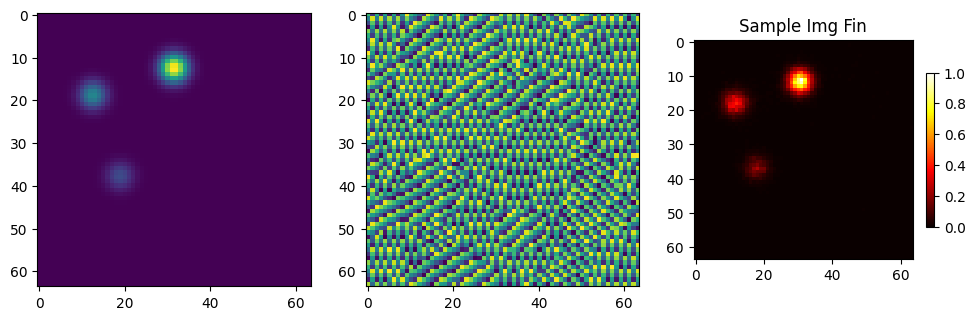

In [ ]:
def Nspots(xx,yy,xc,ss,intx):
  ns    = xc.shape[0]
  print (xx.shape)
  Mat   = np.zeros(xx.shape)
  for i in range(ns):
    Mat = Mat + intx[i]*np.exp(-(xx-xc[i,0])**2 /ss[i]**2  - (yy-xc[i,1])**2 / ss[i]**2)
  return (Mat)

F,A = plt.subplots(1,3,figsize=(12,4))

xxm   = xx.min()
xxM   = xx.max()
delta = xxM - xxm

xc = np.zeros((3,2))
ss = np.zeros((3))
intx = np.zeros((3))

xc[0,0] =  xxm + delta *0.3
xc[0,1] =  xxm + delta *0.6
xc[1,0] =  xxM - delta * 0.8
xc[1,1] =  xxM - delta * 0.7
xc[2,0] =  xxm + delta * 0.5
xc[2,1] =  xxM - delta * 0.8

ss[0] = ss[1] = ss[2] = 1
intx[0] = 2
intx[1] = 4
intx[2] = 9

Mat   = Nspots(xx,yy,xc,ss,intx)
A[0].imshow(Mat)

####### now find the GS phase

#Phase = GS_Python(img, maxIter)   ### standard FT GS
maxIter   = 150 #fior the GS algorithm
Phase     = GS_Python(Mat, maxIter)   ### standard FT GS
A[1].imshow(Phase )
###final, but needs to be flipped ud and lr
E_sample    = np.fft.fft2(np.exp(1j*Phase))
img_fin     = np.abs(E_sample)**2
img_fin     = (img_fin-img_fin.min()) / (img_fin.max()-img_fin.min())
img_fin     = np.flipud(np.fliplr(img_fin))  ##### FLIP
A1          = A[2].imshow(img_fin,cmap='hot')
A[2].set_title('Sample Img Fin')
plt.colorbar(A1,ax=A[2],shrink=0.5)
print (img_fin.shape)

## find maxima
mw = 5
max1   = img_fin.max()
imax1  = int(img_fin.argmax() // img_fin.shape[0])
jmax1 = int(img_fin.argmax() % img_fin.shape[1])
print ('1:',imax1,jmax1,max1)
img_fin[imax1-mw:imax1+mw,jmax1-mw:jmax1+mw] =0

max2   = img_fin.max()
imax2  = int(img_fin.argmax() // img_fin.shape[0])
jmax2 = int(img_fin.argmax() % img_fin.shape[1])
print ('2:',imax2,jmax2,max2)
img_fin[imax2-mw:imax2+mw,jmax2-mw:jmax2+mw] =0

max3   = img_fin.max()
imax3  = int(img_fin.argmax() // img_fin.shape[0])
jmax3 = int(img_fin.argmax() % img_fin.shape[1])
print ('3:',imax3,jmax3,max3)
img_fin[imax3-mw:imax3+mw,jmax3-mw:jmax3+mw] =0

print (max1,max2,max3)
print (9*max1/max1,9*max2/max1,9*max3/max1)

Phase4 = Phase

(array([ 15.,  31.,  55.,  72.,  83., 101., 121., 119., 113., 135., 128.,
        165., 212., 271., 270., 317., 301., 293., 261., 190., 192., 178.,
        121.,  93.,  58.,  75.,  44.,  37.,  29.,  16.]),
 array([-6.21494204, -5.80355079, -5.39215955, -4.9807683 , -4.56937706,
        -4.15798581, -3.74659457, -3.33520332, -2.92381208, -2.51242083,
        -2.10102959, -1.68963834, -1.2782471 , -0.86685585, -0.45546461,
        -0.04407336,  0.36731788,  0.77870913,  1.19010037,  1.60149162,
         2.01288286,  2.42427411,  2.83566535,  3.2470566 ,  3.65844784,
         4.06983909,  4.48123033,  4.89262158,  5.30401282,  5.71540407,
         6.12679531]),
 <BarContainer object of 30 artists>)

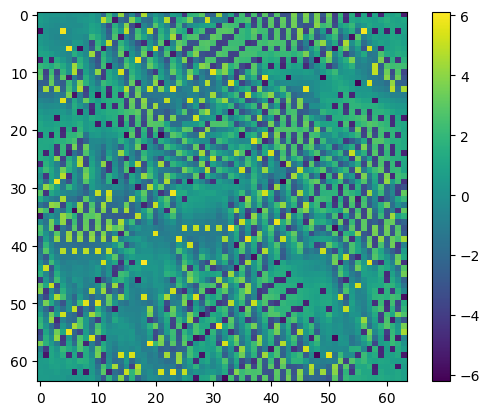

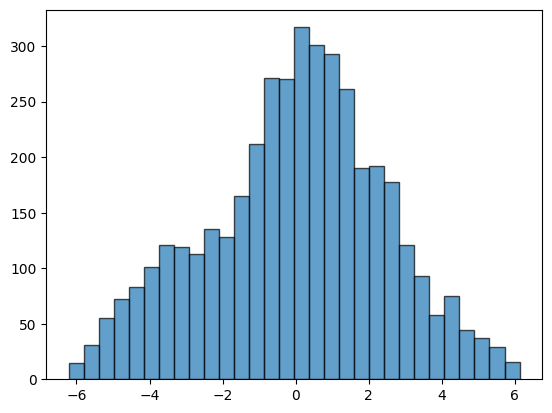

In [ ]:
Err = Phase4 - Phase3
plt.figure()
plt.imshow(Err)
plt.colorbar()
plt.figure()
values = Err.flatten()
plt.hist(values, bins=30, edgecolor='black', alpha=0.7)  # 30 bins for better distributionplipl
